# RNNs and LSTMs: Classifying Heartbeats

CNNs exploit spatial structure in images. But some data has temporal structure — the order matters. A blood pressure of 180 means something very different if the previous reading was 120 (sudden spike) versus 175 (stable-high). ECG signals, vital signs over time, clinical notes word-by-word — these are all sequences where position carries information.

Recurrent Neural Networks (RNNs) process sequences one step at a time, maintaining a hidden state that carries information forward. In this demo we'll classify ECG heartbeat recordings using first a SimpleRNN, then an LSTM — and see why the gating mechanism matters.

## Setup

In [1]:
%pip install -q numpy matplotlib tensorflow seaborn scikit-learn

# NOTE: We skip tensorflow-metal here — Metal GPU doesn't optimize RNN/LSTM
# operations well, and CPU is actually faster for this small dataset.

%reset -f

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
# Force CPU for RNN training (Metal GPU is slower for recurrent layers)
tf.config.set_visible_devices([], 'GPU')

from tensorflow import keras
from keras import Sequential
from keras.layers import SimpleRNN, LSTM, Dense, Dropout, Input
from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

REBUILD = False
ECG_CLASSES = ['Normal', 'Supraventricular', 'Premature Ventricular', 'Fusion', 'Unknown']

%mkdir -p models ECG5000

## Load ECG5000

The ECG5000 dataset contains 5,000 heartbeat recordings from a single patient. Each recording is 140 time steps of voltage measurements, classified into 5 heartbeat types. This is real clinical data — the kind of signal processing that deep learning is increasingly used for in cardiology.

In [3]:
ECG_TRAIN = 'ECG5000/ECG5000_TRAIN.txt'
ECG_TEST = 'ECG5000/ECG5000_TEST.txt'

# Download if not present locally
if not os.path.exists(ECG_TRAIN):
    !curl -sL --create-dirs -o {ECG_TRAIN} 'https://data.badmath.org/ECG5000_TRAIN.txt'
if not os.path.exists(ECG_TEST):
    !curl -sL --create-dirs -o {ECG_TEST} 'https://data.badmath.org/ECG5000_TEST.txt'

# Load data: first column = label (1-5), remaining 140 columns = voltage
train_data = np.loadtxt(ECG_TRAIN)
test_data = np.loadtxt(ECG_TEST)

# Combine and reshuffle for a better train/test ratio (original is 500/4500)
all_data = np.vstack([train_data, test_data])
np.random.seed(42)
np.random.shuffle(all_data)

split = int(0.8 * len(all_data))
X_train = all_data[:split, 1:]    # 140 time steps
y_train = all_data[:split, 0]     # labels 1-5
X_test = all_data[split:, 1:]
y_test = all_data[split:, 0]

print(f"Training: {X_train.shape} ({len(X_train)} beats, 140 time steps each)")
print(f"Test:     {X_test.shape}")
print(f"Classes:  {sorted(np.unique(y_train).astype(int))}")

Training: (4000, 140) (4000 beats, 140 time steps each)
Test:     (1000, 140)
Classes:  [1, 2, 3, 4, 5]


## Visualize ECG Signals

What does a heartbeat look like? Let's plot multiple consecutive normal beats to see the rhythmic pattern, then compare the 5 heartbeat types.

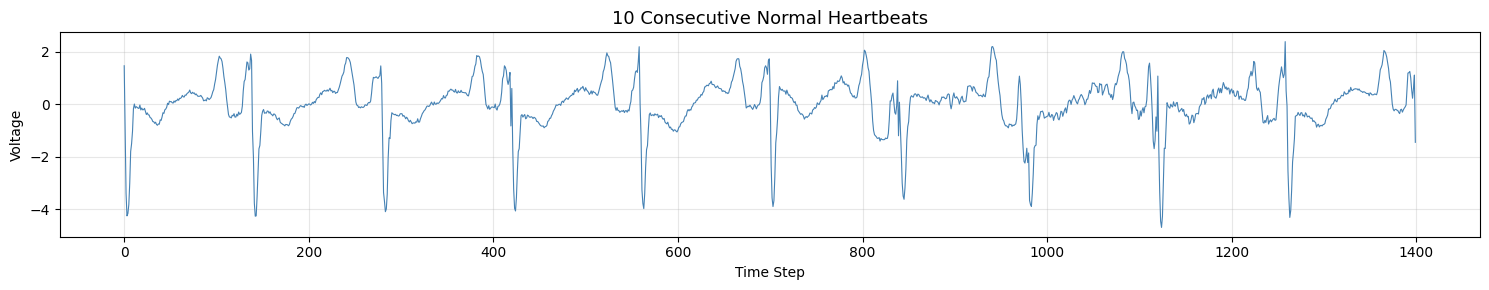

In [4]:
# Multi-beat trace: 10 consecutive normal heartbeats
normal_idx = np.where(y_train == 1.0)[0]
multi_beat = np.concatenate(X_train[normal_idx[:10]])

plt.figure(figsize=(15, 3))
plt.plot(multi_beat, color='steelblue', linewidth=0.8)
plt.title('10 Consecutive Normal Heartbeats', fontsize=13)
plt.xlabel('Time Step')
plt.ylabel('Voltage')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

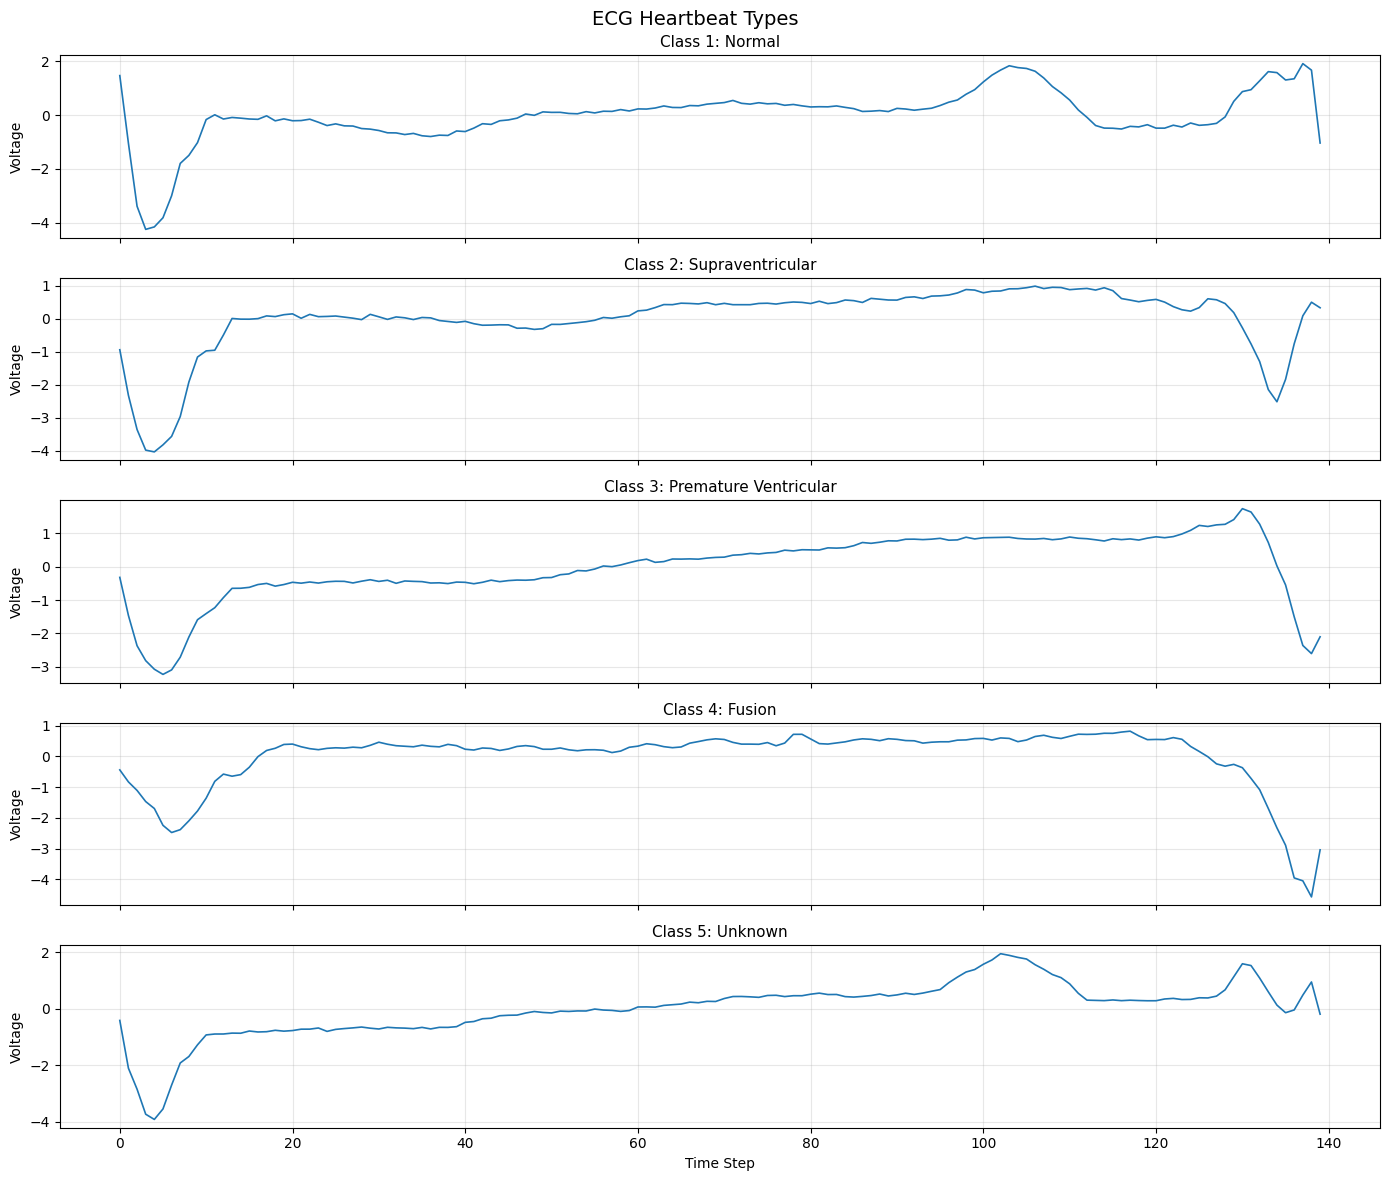

In [5]:
# One example from each class
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
for i, cls in enumerate(sorted(np.unique(y_train))):
    idx = np.where(y_train == cls)[0][0]
    axes[i].plot(X_train[idx], linewidth=1.2)
    axes[i].set_title(f'Class {int(cls)}: {ECG_CLASSES[i]}', fontsize=11)
    axes[i].set_ylabel('Voltage')
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('Time Step')
plt.suptitle('ECG Heartbeat Types', fontsize=14)
plt.tight_layout()
plt.show()

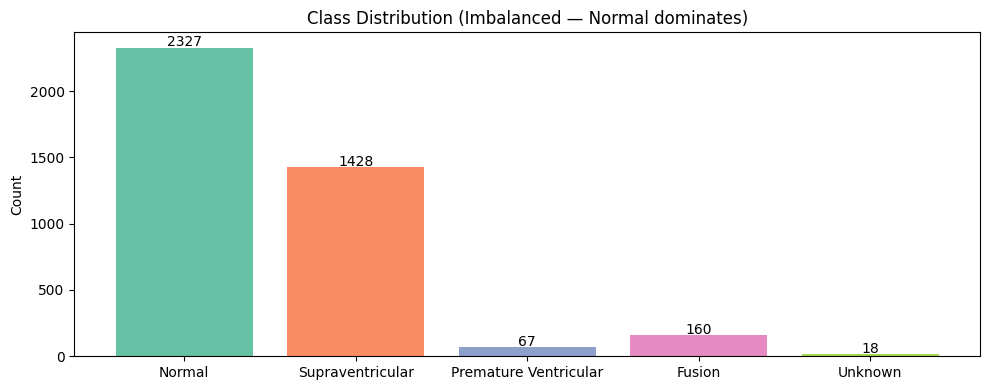

In [6]:
# Class distribution — note the imbalance
unique, counts = np.unique(y_train, return_counts=True)
colors = sns.color_palette('Set2', len(unique))

plt.figure(figsize=(10, 4))
bars = plt.bar([ECG_CLASSES[int(c)-1] for c in unique], counts, color=colors)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(count), ha='center', fontsize=10)
plt.title('Class Distribution (Imbalanced — Normal dominates)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Normal heartbeats dominate the dataset — common in clinical data. The model will likely perform best on the majority class.

## Prepare Data

ECG voltage values aren't bounded to [0, 255] like pixels. We use `StandardScaler` (mean=0, std=1) instead of simple division. Then reshape for RNN input: `(samples, 140 timesteps, 1 feature)`.

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # fit on train only!

# Reshape for RNN: (samples, timesteps, features)
X_train_rnn = X_train_scaled.reshape(-1, 140, 1)
X_test_rnn = X_test_scaled.reshape(-1, 140, 1)

# Labels: convert from 1-5 to 0-4, then one-hot encode
y_train_idx = (y_train - 1).astype(int)
y_test_idx = (y_test - 1).astype(int)
y_train_cat = to_categorical(y_train_idx, 5)
y_test_cat = to_categorical(y_test_idx, 5)

print(f"RNN input shape: {X_train_rnn.shape}")
print(f"Labels shape:    {y_train_cat.shape}")

RNN input shape: (4000, 140, 1)
Labels shape:    (4000, 5)


## SimpleRNN: A First Attempt

SimpleRNN processes one time step at a time, updating a hidden state at each step. For short sequences this works fine, but for 140 steps the gradients can vanish — early time steps barely influence the final output.

In [8]:
model_rnn = Sequential([
    Input(shape=(140, 1)),
    SimpleRNN(32),
    Dense(5, activation='softmax')
])

model_rnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,253 (4.89 KB)

 Trainable params: 1,253 (4.89 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
RNN_PATH = 'models/ecg_simple_rnn.keras'
RNN_HIST = RNN_PATH + '.history.pkl'

if not REBUILD:
    if not os.path.exists(RNN_PATH):
        !curl -fSL -o {RNN_PATH} 'https://data.badmath.org/ecg_simple_rnn.keras' 2>/dev/null
    if not os.path.exists(RNN_HIST):
        !curl -fSL -o {RNN_HIST} 'https://data.badmath.org/ecg_simple_rnn.keras.history.pkl' 2>/dev/null

if REBUILD or not os.path.exists(RNN_PATH):
    history_rnn = model_rnn.fit(
        X_train_rnn, y_train_cat,
        epochs=20,
        batch_size=32,
        validation_split=0.1
    )
    model_rnn.save(RNN_PATH)
    with open(RNN_HIST, 'wb') as f:
        pickle.dump(history_rnn.history, f)
    hist_rnn = history_rnn.history
else:
    model_rnn = keras.models.load_model(RNN_PATH)
    with open(RNN_HIST, 'rb') as f:
        hist_rnn = pickle.load(f)

rnn_loss, rnn_acc = model_rnn.evaluate(X_test_rnn, y_test_cat, verbose=0)
print(f"SimpleRNN test accuracy: {rnn_acc:.2%}")

Epoch 1/20


  1/113 ━━━━━━━━━━━━━━━━━━━━ 33s 302ms/step - accuracy: 0.2500 - loss: 1.7235

 17/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4565 - loss: 1.4946   

 33/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5881 - loss: 1.3108

 50/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6602 - loss: 1.1687

...

 81/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9492 - loss: 0.1977

 97/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9490 - loss: 0.1977

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9486 - loss: 0.1987

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9453 - loss: 0.2078 - val_accuracy: 0.9175 - val_loss: 0.2872


SimpleRNN test accuracy: 92.80%


## LSTM: Long-Term Memory

SimpleRNN struggles because gradients vanish over 140 time steps. LSTM adds three gates (forget, input, output) that control what information to keep, store, and pass on. This lets it retain relevant patterns across the full sequence.

In [10]:
model_lstm = Sequential([
    Input(shape=(140, 1)),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

model_lstm.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,141 (74.77 KB)

 Trainable params: 19,141 (74.77 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
LSTM_PATH = 'models/ecg_lstm.keras'
LSTM_HIST = LSTM_PATH + '.history.pkl'

if not REBUILD:
    if not os.path.exists(LSTM_PATH):
        !curl -fSL -o {LSTM_PATH} 'https://data.badmath.org/ecg_lstm.keras' 2>/dev/null
    if not os.path.exists(LSTM_HIST):
        !curl -fSL -o {LSTM_HIST} 'https://data.badmath.org/ecg_lstm.keras.history.pkl' 2>/dev/null

if REBUILD or not os.path.exists(LSTM_PATH):
    callbacks = [
        ModelCheckpoint(LSTM_PATH, save_best_only=True, monitor='val_accuracy'),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    ]
    history_lstm = model_lstm.fit(
        X_train_rnn, y_train_cat,
        epochs=30,
        batch_size=32,
        validation_split=0.1,
        callbacks=callbacks
    )
    model_lstm.save(LSTM_PATH)
    with open(LSTM_HIST, 'wb') as f:
        pickle.dump(history_lstm.history, f)
    hist_lstm = history_lstm.history
else:
    model_lstm = keras.models.load_model(LSTM_PATH)
    with open(LSTM_HIST, 'rb') as f:
        hist_lstm = pickle.load(f)

lstm_loss, lstm_acc = model_lstm.evaluate(X_test_rnn, y_test_cat, verbose=0)
print(f"LSTM test accuracy: {lstm_acc:.2%}")

Epoch 1/30


  1/113 ━━━━━━━━━━━━━━━━━━━━ 54s 489ms/step - accuracy: 0.3125 - loss: 1.6008

  6/113 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4249 - loss: 1.5663  

 10/113 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5035 - loss: 1.5464

 14/113 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5523 - loss: 1.5264

...

101/113 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9595 - loss: 0.1341

106/113 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9594 - loss: 0.1346

111/113 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9592 - loss: 0.1352

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9558 - loss: 0.1482 - val_accuracy: 0.9175 - val_loss: 0.2520


LSTM test accuracy: 93.80%


## Training Curves

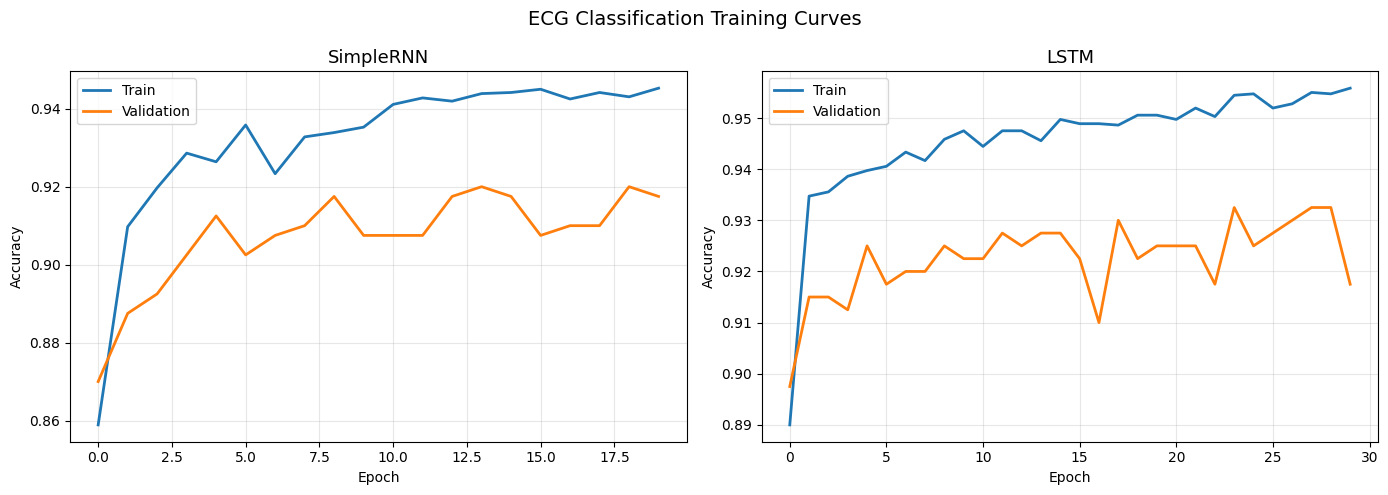

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_rnn['accuracy'], label='Train', linewidth=2)
axes[0].plot(hist_rnn['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('SimpleRNN', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_lstm['accuracy'], label='Train', linewidth=2)
axes[1].plot(hist_lstm['val_accuracy'], label='Validation', linewidth=2)
axes[1].set_title('LSTM', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('ECG Classification Training Curves', fontsize=14)
plt.tight_layout()
plt.show()

## Evaluate the LSTM

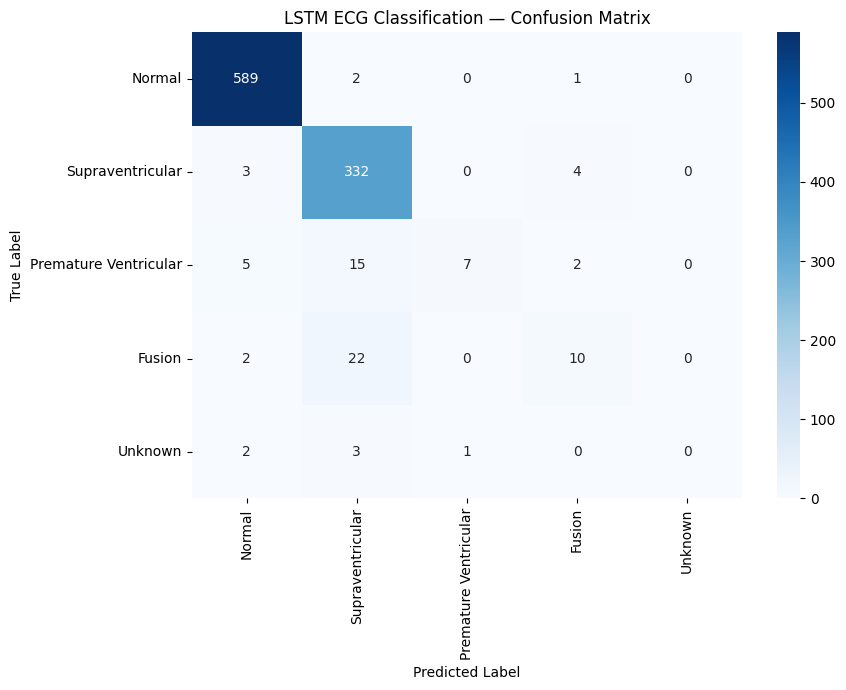

In [13]:
# Confusion matrix
y_pred = model_lstm.predict(X_test_rnn, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test_idx, y_pred_classes)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ECG_CLASSES, yticklabels=ECG_CLASSES)
plt.title('LSTM ECG Classification — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [14]:
# Per-class metrics
print(classification_report(y_test_idx, y_pred_classes, target_names=ECG_CLASSES))

                       precision    recall  f1-score   support

               Normal       0.98      0.99      0.99       592
     Supraventricular       0.89      0.98      0.93       339
Premature Ventricular       0.88      0.24      0.38        29
               Fusion       0.59      0.29      0.39        34
              Unknown       0.00      0.00      0.00         6

             accuracy                           0.94      1000
            macro avg       0.67      0.50      0.54      1000
         weighted avg       0.93      0.94      0.92      1000



/Users/christopher/Documents/datasci_223/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/christopher/Documents/datasci_223/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/christopher/Documents/datasci_223/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

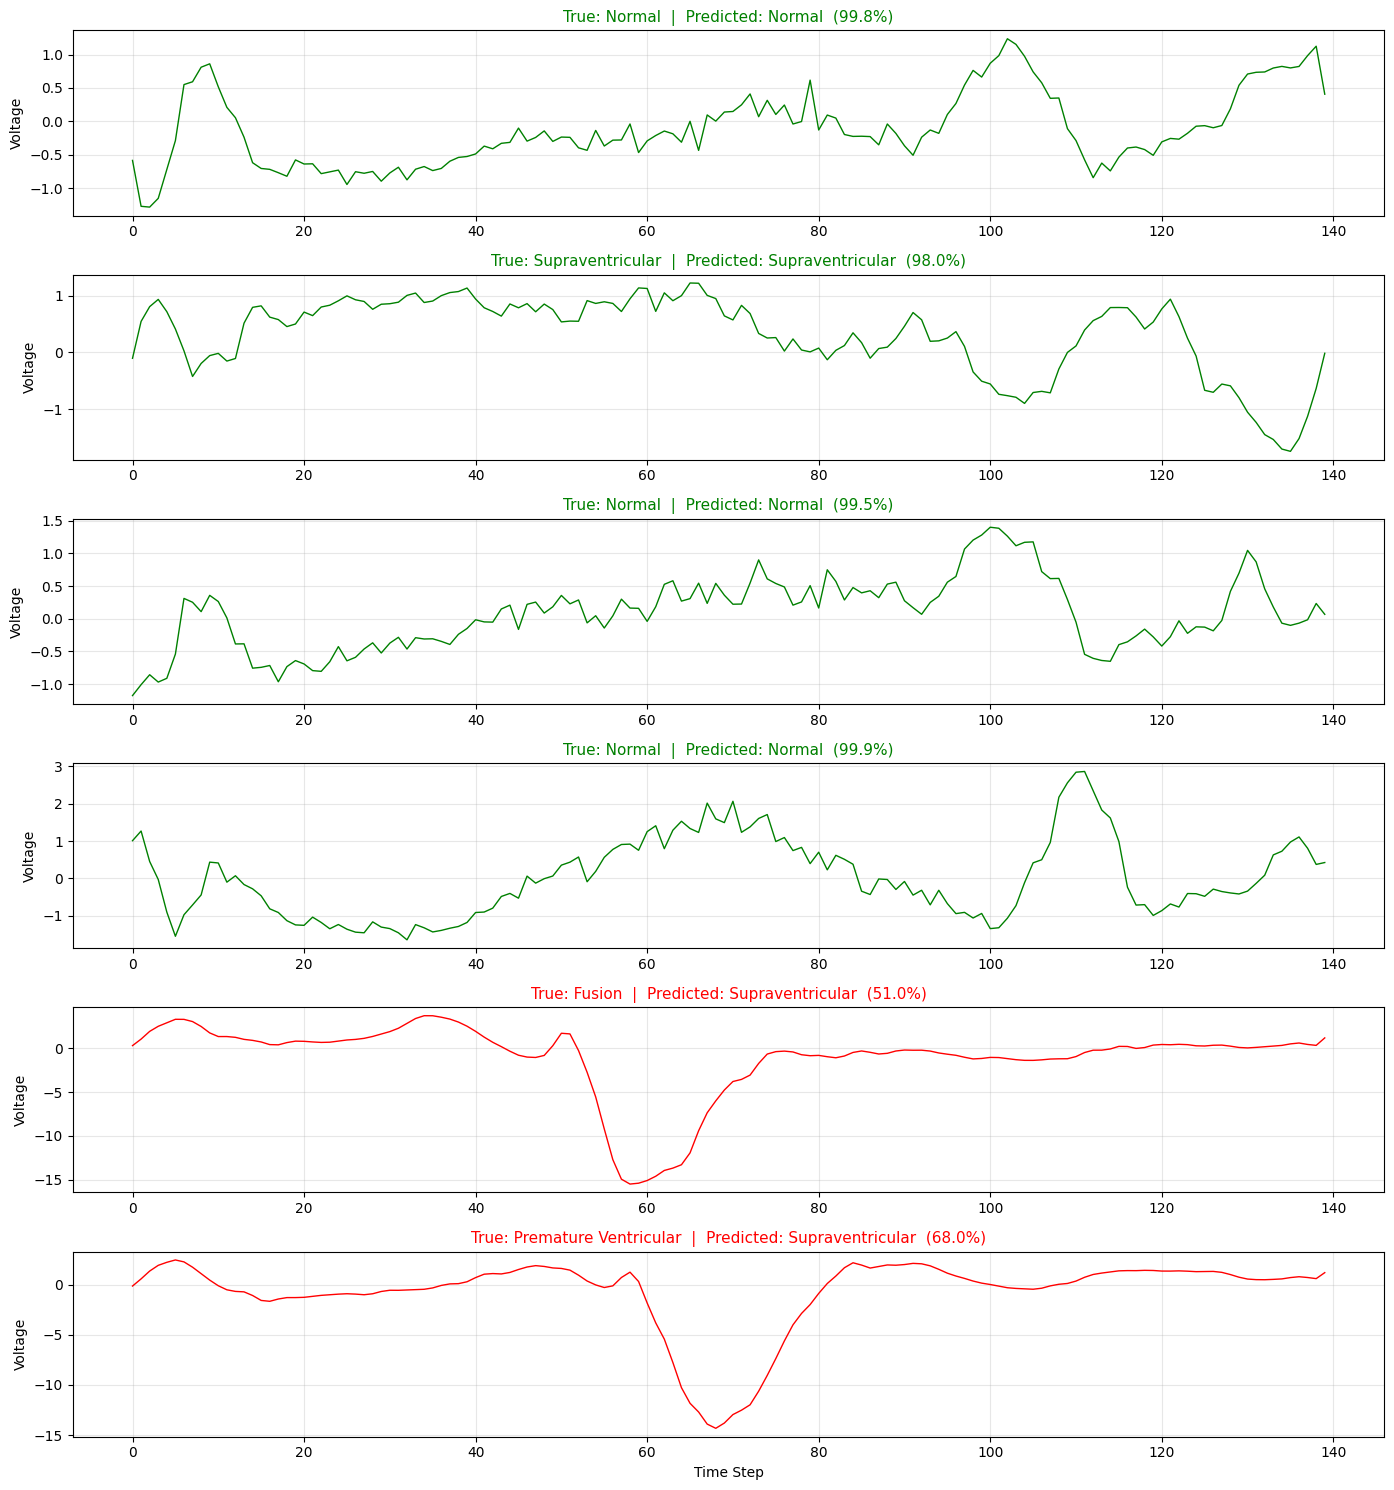

In [15]:
# ECG prediction strips with confidence
def plot_ecg_predictions(X, y_true, y_pred, confidences, class_names, n=6):
    """Show ECG traces with true/predicted labels, color-coded correct/wrong."""
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.5 * n))
    for i in range(n):
        correct = y_true[i] == y_pred[i]
        color = 'green' if correct else 'red'
        axes[i].plot(X[i].flatten(), color=color, linewidth=1)
        axes[i].set_title(
            f"True: {class_names[y_true[i]]}  |  "
            f"Predicted: {class_names[y_pred[i]]}  "
            f"({confidences[i]:.1%})",
            color=color, fontsize=11
        )
        axes[i].set_ylabel('Voltage')
        axes[i].grid(True, alpha=0.3)
    axes[-1].set_xlabel('Time Step')
    plt.tight_layout()
    plt.show()

# Pick a mix of correct and incorrect predictions
confidences = np.max(y_pred, axis=1)
wrong_mask = y_pred_classes != y_test_idx
correct_mask = ~wrong_mask

# 4 correct + 2 wrong (if available)
n_wrong = min(2, wrong_mask.sum())
n_correct = 6 - n_wrong
sample_idx = np.concatenate([
    np.where(correct_mask)[0][:n_correct],
    np.where(wrong_mask)[0][:n_wrong]
])

plot_ecg_predictions(
    X_test_scaled[sample_idx],
    y_test_idx[sample_idx],
    y_pred_classes[sample_idx],
    confidences[sample_idx],
    ECG_CLASSES
)

## SimpleRNN vs. LSTM

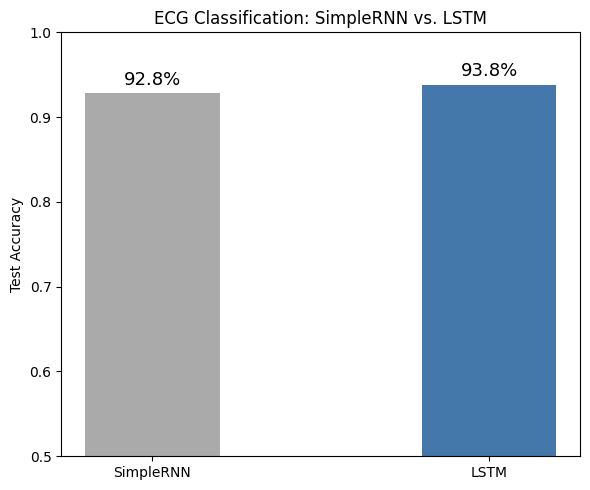

In [16]:
models_compared = ['SimpleRNN', 'LSTM']
accs = [rnn_acc, lstm_acc]
colors = ['#aaaaaa', '#4477AA']

plt.figure(figsize=(6, 5))
bars = plt.bar(models_compared, accs, color=colors, width=0.4)
plt.ylabel('Test Accuracy')
plt.title('ECG Classification: SimpleRNN vs. LSTM')
plt.ylim(0.5, 1.0)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.1%}', ha='center', fontsize=13)
plt.tight_layout()
plt.show()

The LSTM's gating mechanism makes a meaningful difference on this 140-step sequence. For shorter sequences the gap would be smaller; for longer sequences (hundreds of time steps) it would be even larger.

## Recap: Matching Architecture to Data

Across Demos 2 and 3, we've built three types of models:

| Architecture | Dataset | Structure Exploited | Approx. Accuracy |
|:---|:---|:---|:---|
| **Dense** | CIFAR-10 (images) | None (flattened) | ~38% |
| **CNN** | CIFAR-10 (images) | Spatial (2D neighbors) | ~57% |
| **LSTM** | ECG5000 (time series) | Temporal (sequence order) | ~94% |

The lesson: **match the architecture to your data's structure.** Dense layers are a baseline. CNNs see spatial patterns. RNNs remember sequences. Choosing the right architecture matters more than tuning hyperparameters.

And neural networks aren't always the answer. For tabular data with fewer than 10,000 rows, Random Forest or XGBoost from last lecture often wins — and they're far easier to explain to a clinician.